# MNIST Classifier with Mixture of Experts (MOE)

This notebook implements a deep neural network using the **Mixture of Experts** concept for MNIST digit classification.

## MOE Architecture:
- **Expert Networks**: Multiple specialized neural networks that learn different aspects of the data
- **Gating Network**: A network that learns to route inputs to the most appropriate experts
- **Sparse Gating**: Only top-k experts are activated for each input (efficient computation)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Load MNIST Dataset

In [2]:
# Data transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load MNIST dataset
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

# Data loaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.22MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 180kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.76MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.22MB/s]

Training samples: 60000
Test samples: 10000


## Define Expert Network

Each expert is a small deep neural network that specializes in recognizing certain patterns.

In [9]:
class Expert(nn.Module):
    """
    Individual Expert Network - A deep MLP that processes input features
    Using LayerNorm instead of BatchNorm to handle variable batch sizes per expert
    """
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.1):
        super(Expert, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),  # LayerNorm works with any batch size
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return self.network(x)

## Define Gating Network

The gating network learns to route inputs to the most appropriate experts using a softmax distribution.

In [10]:
class GatingNetwork(nn.Module):
    """
    Gating Network - Determines which experts to use for each input
    Implements top-k sparse gating with noise for load balancing
    """
    def __init__(self, input_dim, num_experts, top_k=2):
        super(GatingNetwork, self).__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        
        # Gating network with learnable parameters
        self.gate = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, num_experts)
        )
        
        # Noise for load balancing during training
        self.noise_weight = nn.Parameter(torch.zeros(1, num_experts))
        
    def forward(self, x, training=True):
        # Get raw gate logits
        gate_logits = self.gate(x)
        
        # Add noise during training for exploration
        if training:
            noise = torch.randn_like(gate_logits) * F.softplus(self.noise_weight)
            gate_logits = gate_logits + noise
        
        # Get top-k experts
        top_k_logits, top_k_indices = torch.topk(gate_logits, self.top_k, dim=-1)
        
        # Create sparse gate weights (only top-k experts have non-zero weights)
        top_k_weights = F.softmax(top_k_logits, dim=-1)
        
        # Create full gate output (sparse)
        gate_output = torch.zeros_like(gate_logits)
        gate_output.scatter_(1, top_k_indices, top_k_weights)
        
        return gate_output, top_k_indices, top_k_weights

## Define Mixture of Experts Model

The MOE layer combines multiple experts with a gating mechanism. It also includes load balancing loss to ensure all experts are utilized.

In [11]:
class MoELayer(nn.Module):
    """
    Mixture of Experts Layer
    Combines multiple expert networks with sparse gating
    """
    def __init__(self, input_dim, hidden_dim, output_dim, num_experts=8, top_k=2):
        super(MoELayer, self).__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        
        # Create expert networks
        self.experts = nn.ModuleList([
            Expert(input_dim, hidden_dim, output_dim)
            for _ in range(num_experts)
        ])
        
        # Gating network
        self.gating = GatingNetwork(input_dim, num_experts, top_k)
        
    def forward(self, x, training=True):
        batch_size = x.shape[0]
        
        # Get gating weights
        gate_output, top_k_indices, top_k_weights = self.gating(x, training)
        
        # Compute expert outputs (only for selected experts - sparse computation)
        final_output = torch.zeros(batch_size, self.experts[0].network[-1].out_features, device=x.device)
        
        # Process each expert
        for i, expert in enumerate(self.experts):
            # Find which samples use this expert
            expert_mask = (gate_output[:, i] > 0)
            if expert_mask.any():
                expert_input = x[expert_mask]
                expert_output = expert(expert_input)
                final_output[expert_mask] += gate_output[expert_mask, i:i+1] * expert_output
        
        # Calculate load balancing loss (auxiliary loss)
        # Encourages uniform distribution of samples across experts
        expert_usage = gate_output.mean(dim=0)  # Average usage per expert
        load_balance_loss = self.num_experts * (expert_usage * expert_usage).sum()
        
        return final_output, load_balance_loss, gate_output

## Complete MNIST MOE Classifier

Deep neural network with MOE layers for MNIST classification.

In [18]:
class MNISTMoEClassifier(nn.Module):
    """
    Deep MNIST Classifier using Mixture of Experts
    
    Architecture:
    - Input embedding layer
    - Multiple MOE layers
    - Output classification head
    """
    def __init__(self, num_experts=8, top_k=2):
        super(MNISTMoEClassifier, self).__init__()
        
        self.input_dim = 28 * 28  # MNIST image size
        self.num_classes = 10
        
        # Input embedding
        self.input_embed = nn.Sequential(
            nn.Linear(self.input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.1)
        )
        
        # First MOE Layer
        self.moe_layer1 = MoELayer(
            input_dim=256,
            hidden_dim=128,
            output_dim=256,
            num_experts=num_experts,
            top_k=top_k
        )
        
        # Intermediate processing
        self.intermediate = nn.Sequential(
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.1)
        )
        
        # Second MOE Layer
        self.moe_layer2 = MoELayer(
            input_dim=256,
            hidden_dim=128,
            output_dim=128,
            num_experts=num_experts,
            top_k=top_k
        )
        
        # Output classification head
        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, self.num_classes)
        )
        
    def forward(self, x, training=True):
        # Flatten input
        x = x.view(x.size(0), -1)
        
        # Input embedding
        x = self.input_embed(x)
        
        # First MOE layer
        x, lb_loss1, gate1 = self.moe_layer1(x, training)
        x = self.intermediate(x)
        
        # Second MOE layer
        x, lb_loss2, gate2 = self.moe_layer2(x, training)
        
        # Classification
        logits = self.classifier(x)
        
        # Total load balancing loss
        total_lb_loss = lb_loss1 + lb_loss2
        
        return logits, total_lb_loss, (gate1, gate2)

# Create model
model = MNISTMoEClassifier(num_experts=8, top_k=2).to(device)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

MNISTMoEClassifier(
  (input_embed): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
  )
  (moe_layer1): MoELayer(
    (experts): ModuleList(
      (0-7): 8 x Expert(
        (network): Sequential(
          (0): Linear(in_features=256, out_features=128, bias=True)
          (1): ReLU()
          (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (3): Dropout(p=0.1, inplace=False)
          (4): Linear(in_features=128, out_features=128, bias=True)
          (5): ReLU()
          (6): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (7): Dropout(p=0.1, inplace=False)
          (8): Linear(in_features=128, out_features=256, bias=True)
        )
      )
    )
    (gating): GatingNetwork(
      (gate): Sequential(
        (0): Linear(in_features=256, out_features=128, bias=True)
        (1

## Training Functions

In [19]:
def train_epoch(model, train_loader, optimizer, criterion, device, lb_weight=0.01):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    total_ce_loss = 0
    total_lb_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        logits, lb_loss, gates = model(data, training=True)
        
        # Cross-entropy loss
        ce_loss = criterion(logits, target)
        
        # Total loss = CE loss + load balancing loss
        loss = ce_loss + lb_weight * lb_loss
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        total_loss += loss.item()
        total_ce_loss += ce_loss.item()
        total_lb_loss += lb_loss.item()
        
        _, predicted = logits.max(1)
        total += target.size(0)
        correct += predicted.eq(target).sum().item()
    
    avg_loss = total_loss / len(train_loader)
    avg_ce_loss = total_ce_loss / len(train_loader)
    avg_lb_loss = total_lb_loss / len(train_loader)
    accuracy = 100. * correct / total
    
    return avg_loss, avg_ce_loss, avg_lb_loss, accuracy


def evaluate(model, test_loader, criterion, device):
    """Evaluate the model"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    all_gates1 = []
    all_gates2 = []
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            
            logits, lb_loss, gates = model(data, training=False)
            loss = criterion(logits, target)
            
            total_loss += loss.item()
            _, predicted = logits.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
            
            all_gates1.append(gates[0].cpu())
            all_gates2.append(gates[1].cpu())
    
    avg_loss = total_loss / len(test_loader)
    accuracy = 100. * correct / total
    
    # Concatenate all gates for analysis
    all_gates1 = torch.cat(all_gates1, dim=0)
    all_gates2 = torch.cat(all_gates2, dim=0)
    
    return avg_loss, accuracy, (all_gates1, all_gates2)

## Train the Model

In [20]:
# Training configuration
num_epochs = 10
learning_rate = 0.001
lb_weight = 0.01  # Load balancing loss weight

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Training history
history = {
    'train_loss': [], 'train_acc': [],
    'test_loss': [], 'test_acc': [],
    'ce_loss': [], 'lb_loss': []
}

# Training loop
print("Starting Training...")
print("=" * 60)

for epoch in range(1, num_epochs + 1):
    # Train
    train_loss, ce_loss, lb_loss, train_acc = train_epoch(
        model, train_loader, optimizer, criterion, device, lb_weight
    )
    
    # Evaluate
    test_loss, test_acc, gates = evaluate(model, test_loader, criterion, device)
    
    # Update scheduler
    scheduler.step()
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    history['ce_loss'].append(ce_loss)
    history['lb_loss'].append(lb_loss)
    
    # Print progress
    print(f"Epoch {epoch:2d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} (CE: {ce_loss:.4f}, LB: {lb_loss:.4f}) | "
          f"Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} | "
          f"Test Acc: {test_acc:.2f}%")

print("=" * 60)
print(f"Final Test Accuracy: {test_acc:.2f}%")

Starting Training...
Epoch  1/10 | Train Loss: 0.5594 (CE: 0.5238, LB: 3.5584) | Train Acc: 83.94% | Test Loss: 0.2127 | Test Acc: 94.31%
Epoch  2/10 | Train Loss: 0.2400 (CE: 0.2053, LB: 3.4731) | Train Acc: 94.40% | Test Loss: 0.1500 | Test Acc: 95.97%
Epoch  3/10 | Train Loss: 0.1943 (CE: 0.1600, LB: 3.4304) | Train Acc: 95.59% | Test Loss: 0.1296 | Test Acc: 96.36%
Epoch  4/10 | Train Loss: 0.1673 (CE: 0.1338, LB: 3.3510) | Train Acc: 96.31% | Test Loss: 0.1036 | Test Acc: 97.04%
Epoch  5/10 | Train Loss: 0.1515 (CE: 0.1197, LB: 3.1762) | Train Acc: 96.70% | Test Loss: 0.1088 | Test Acc: 96.91%
Epoch  6/10 | Train Loss: 0.1093 (CE: 0.0782, LB: 3.1165) | Train Acc: 97.78% | Test Loss: 0.0854 | Test Acc: 97.64%


KeyboardInterrupt: 

## Visualize Training Progress

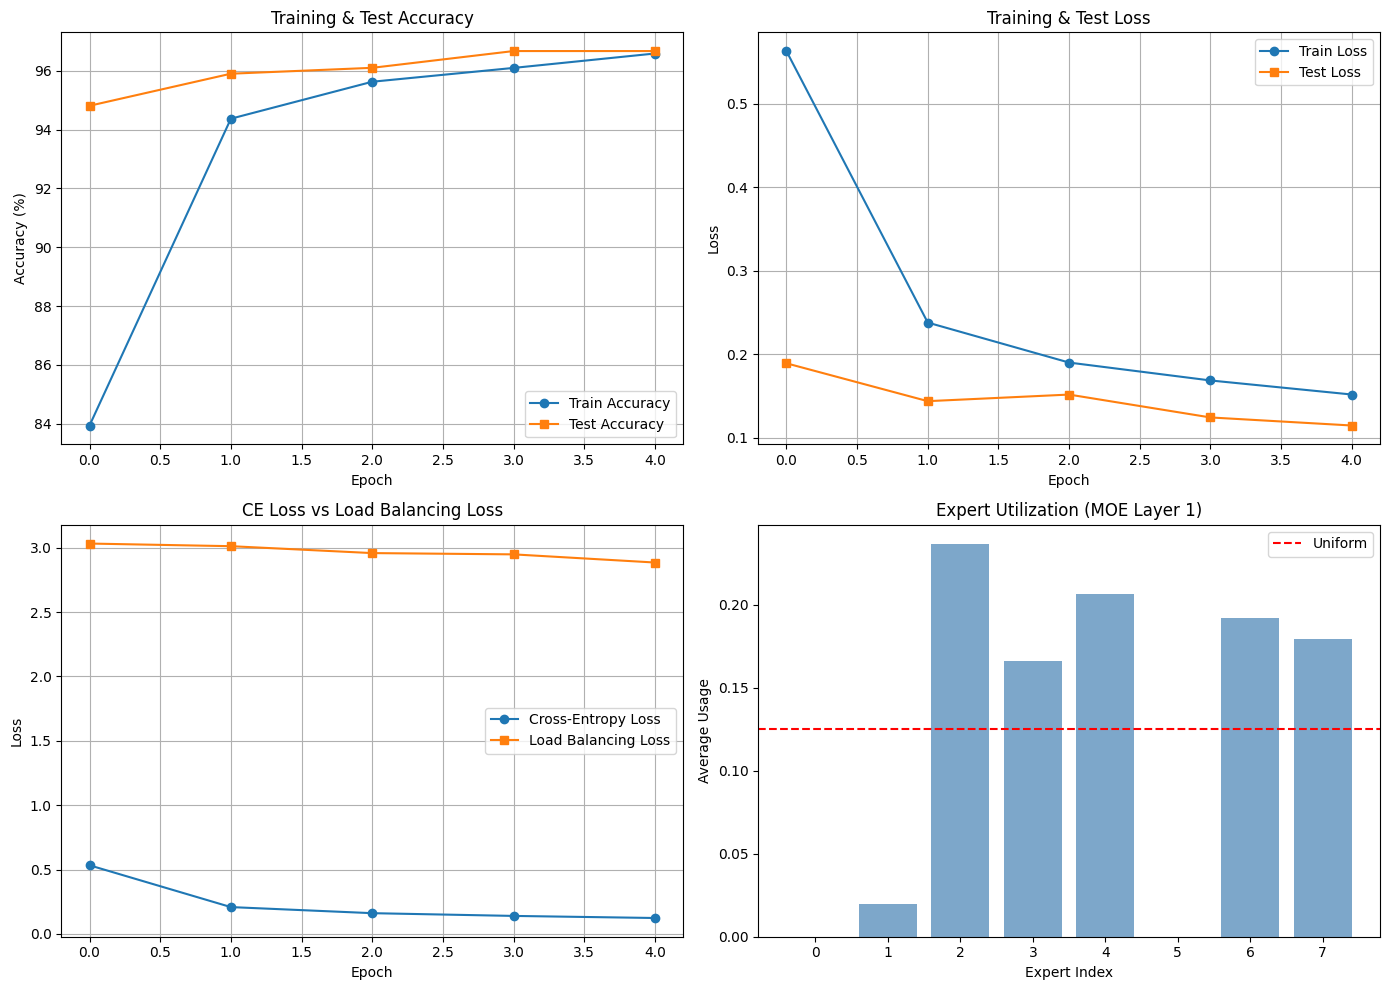

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot accuracy
axes[0, 0].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[0, 0].plot(history['test_acc'], label='Test Accuracy', marker='s')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Training & Test Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot loss
axes[0, 1].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0, 1].plot(history['test_loss'], label='Test Loss', marker='s')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Training & Test Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot CE and LB losses separately
axes[1, 0].plot(history['ce_loss'], label='Cross-Entropy Loss', marker='o')
axes[1, 0].plot(history['lb_loss'], label='Load Balancing Loss', marker='s')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('CE Loss vs Load Balancing Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Expert utilization in MOE Layer 1
gate1_usage = gates[0].mean(dim=0).numpy()
axes[1, 1].bar(range(len(gate1_usage)), gate1_usage, color='steelblue', alpha=0.7)
axes[1, 1].set_xlabel('Expert Index')
axes[1, 1].set_ylabel('Average Usage')
axes[1, 1].set_title('Expert Utilization (MOE Layer 1)')
axes[1, 1].axhline(y=1/len(gate1_usage), color='red', linestyle='--', label='Uniform')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Analyze Expert Specialization

Let's see which experts specialize in which digits!

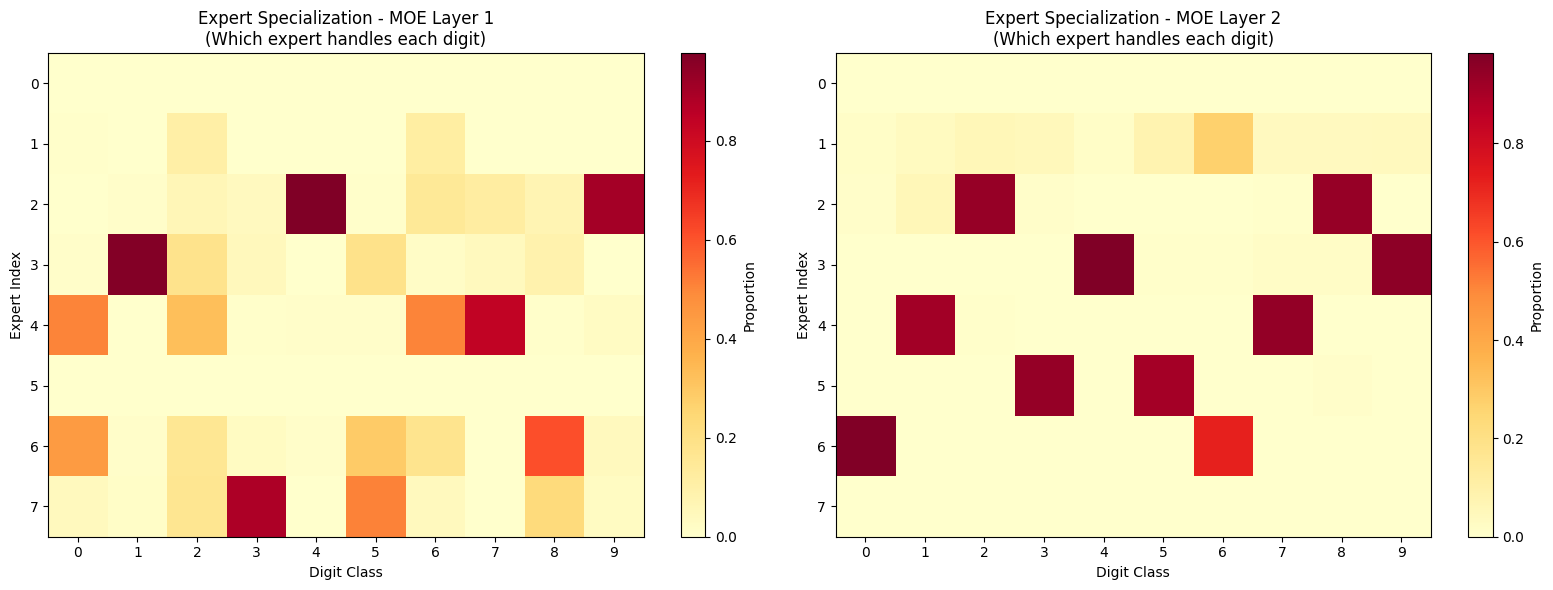

In [16]:
def analyze_expert_specialization(model, test_loader, device):
    """Analyze which experts specialize in which digit classes"""
    model.eval()
    
    expert_digit_counts_l1 = {i: np.zeros(10) for i in range(8)}
    expert_digit_counts_l2 = {i: np.zeros(10) for i in range(8)}
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            
            logits, lb_loss, gates = model(data, training=False)
            gate1, gate2 = gates
            
            # Get primary expert for each sample (MOE Layer 1)
            primary_experts_l1 = gate1.argmax(dim=1).cpu().numpy()
            primary_experts_l2 = gate2.argmax(dim=1).cpu().numpy()
            labels = target.cpu().numpy()
            
            # Count which digits each expert handles
            for expert_idx, digit in zip(primary_experts_l1, labels):
                expert_digit_counts_l1[expert_idx][digit] += 1
            for expert_idx, digit in zip(primary_experts_l2, labels):
                expert_digit_counts_l2[expert_idx][digit] += 1
    
    return expert_digit_counts_l1, expert_digit_counts_l2

# Analyze specialization
expert_counts_l1, expert_counts_l2 = analyze_expert_specialization(model, test_loader, device)

# Create heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MOE Layer 1 heatmap
heatmap_data_l1 = np.array([expert_counts_l1[i] for i in range(8)])
heatmap_data_l1 = heatmap_data_l1 / heatmap_data_l1.sum(axis=0, keepdims=True)  # Normalize per digit

im1 = axes[0].imshow(heatmap_data_l1, cmap='YlOrRd', aspect='auto')
axes[0].set_xlabel('Digit Class')
axes[0].set_ylabel('Expert Index')
axes[0].set_title('Expert Specialization - MOE Layer 1\n(Which expert handles each digit)')
axes[0].set_xticks(range(10))
axes[0].set_yticks(range(8))
plt.colorbar(im1, ax=axes[0], label='Proportion')

# MOE Layer 2 heatmap
heatmap_data_l2 = np.array([expert_counts_l2[i] for i in range(8)])
heatmap_data_l2 = heatmap_data_l2 / heatmap_data_l2.sum(axis=0, keepdims=True)  # Normalize per digit

im2 = axes[1].imshow(heatmap_data_l2, cmap='YlOrRd', aspect='auto')
axes[1].set_xlabel('Digit Class')
axes[1].set_ylabel('Expert Index')
axes[1].set_title('Expert Specialization - MOE Layer 2\n(Which expert handles each digit)')
axes[1].set_xticks(range(10))
axes[1].set_yticks(range(8))
plt.colorbar(im2, ax=axes[1], label='Proportion')

plt.tight_layout()
plt.show()

## Test Predictions on Sample Images

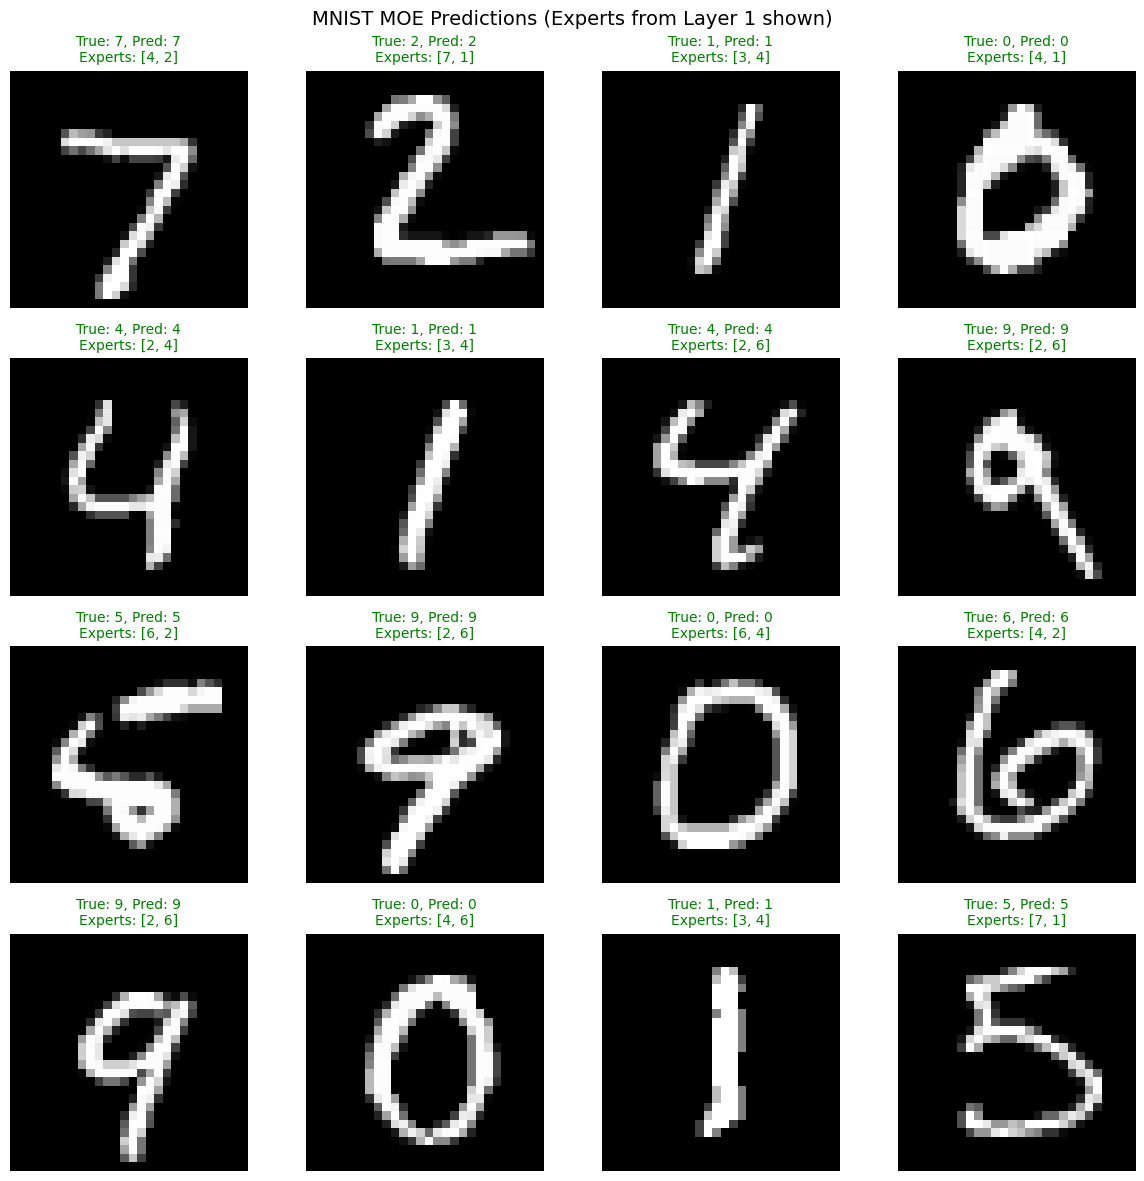

Accuracy on displayed samples: 100.0%


In [17]:
# Get some test samples
test_images, test_labels = next(iter(test_loader))
test_images, test_labels = test_images[:16], test_labels[:16]

# Make predictions
model.eval()
with torch.no_grad():
    logits, _, gates = model(test_images.to(device), training=False)
    predictions = logits.argmax(dim=1).cpu()
    gate1, gate2 = gates

# Visualize
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for idx, ax in enumerate(axes.flat):
    img = test_images[idx].squeeze().numpy()
    true_label = test_labels[idx].item()
    pred_label = predictions[idx].item()
    
    # Get which experts were used
    top_experts_l1 = torch.topk(gate1[idx], 2).indices.tolist()
    
    ax.imshow(img, cmap='gray')
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}, Pred: {pred_label}\nExperts: {top_experts_l1}', 
                 color=color, fontsize=10)
    ax.axis('off')

plt.suptitle('MNIST MOE Predictions (Experts from Layer 1 shown)', fontsize=14)
plt.tight_layout()
plt.show()

# Print accuracy on these samples
accuracy = (predictions == test_labels).float().mean() * 100
print(f"Accuracy on displayed samples: {accuracy:.1f}%")